# Iris Flower Classification using Machine Learning

In [3]:
import pandas as pd

df = pd.read_csv('/content/IRIS.csv')

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.isnull().sum()


,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


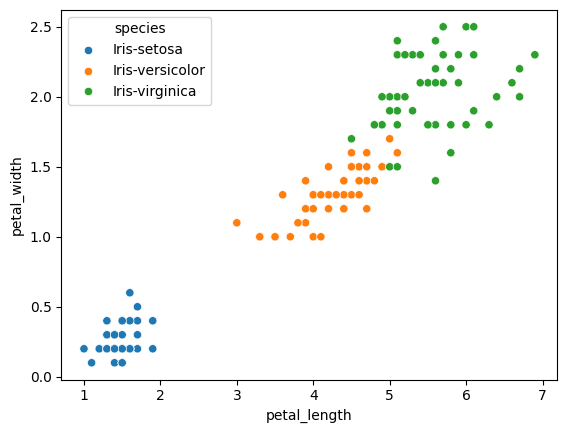

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x='petal_length',
    y='petal_width',
    hue='species',
    data=df
)

plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['species'] = encoder.fit_transform(df['species'])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
X = df.drop('species', axis=1)

y = df['species']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [12]:
knn_pred = knn.predict(X_test)

print(knn_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, knn_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


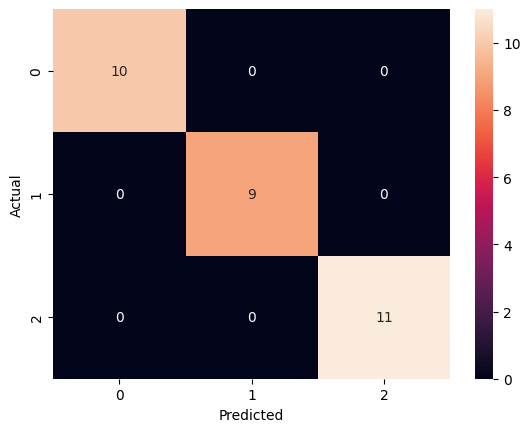

In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, knn_pred)

sns.heatmap(cm, annot=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [16]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [17]:
lr_pred = lr.predict(X_test)

print(lr_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [18]:
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 1.0


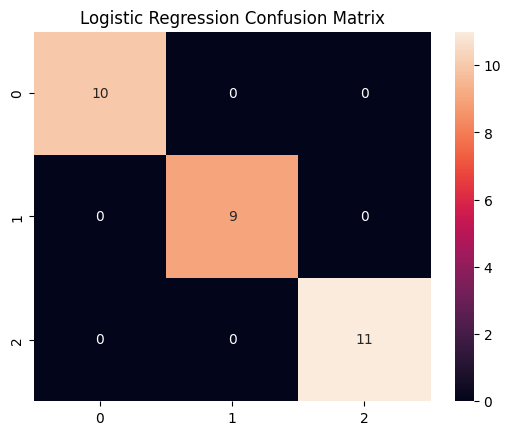

In [19]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True)

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [20]:
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [22]:
dt_pred = dt.predict(X_test)

print(dt_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [23]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 1.0


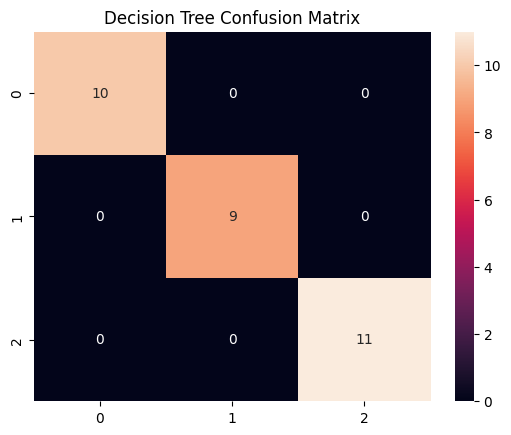

In [24]:
cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm, annot=True)

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [25]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Model Comparision

In [26]:
print("KNN Accuracy:", accuracy)

print("Logistic Regression Accuracy:", lr_accuracy)

print("Decision Tree Accuracy:", dt_accuracy)

KNN Accuracy: 1.0
Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


In [27]:
import joblib

joblib.dump(knn, 'best_model.pkl')

['best_model.pkl']

In [28]:
model = joblib.load('best_model.pkl')

sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
